# Example: Transcriptional Dynamics

The following applies minibatch and adaptive minibatch SMC ABC to the problem of estimating parameters from a transcriptional dynamics snapshot model of smFISH (single-molecule Fluorescent in situ Hybridization). The heterogeneity in these models is given by the shape (length L in this case) and transcription start site (z). The model is of bursty expression, following:


Will be filled out later

In [15]:
## Import smc abc class and schemes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_schemes as schemes
import smc_abc_utils as utils
import numpy as np

from matplotlib import pyplot as plt

#A class that generates smfish transcriptional dynamics snapshots
import transcriptional_dynamics as td
smfish_sims = td.snapshot_simulator()


## Constant Minibatch SMC ABC

In [ ]:
#### Model parameters 
sample_size = 300
kplus = 30
kminus = 10
rburst = 10
diffusivity = 0.1

true_params = np.array([kplus,rburst,diffusivity])
num_params = true_params.shape[0]


T,dt = 5,0.01
bp,gp = 2,4
lengths = np.random.gamma(shape = gp, scale = 1/gp, size = (sample_size,))
sites = np.random.beta(a = bp,b = bp, size = (sample_size,)) * lengths

# homogeneous
#lengths = np.ones(shape = (sample_size,))
#sites = 0.5*lengths

length_index = np.arange(sample_size)
print(np.var(lengths), np.var(sites))


def bndry_func(x,ind,i=length_index): # ind is the wrong kind of indices, these are internal to the smfish simulator.
    return (x > 0) & (x < lengths[i[ind]])
data_ = smfish_sims.simulate(kplus, kminus, rburst, diffusivity, T, dt, sites, bndry_func)
data = np.array([np.asarray(d) for d in data_],dtype=object)


def model(p,i):
    z = sites[i,]
    bfunc = lambda x,ind: bndry_func(x,ind,i=i)
    #ref_data = [data[x] for x in i]
    obs_data = data[i]
    sim = np.array(smfish_sims.simulate(p[0], kminus, p[1], p[2], T, dt, z, bfunc),dtype = object)
    return sim, obs_data


#### Estimation parameters
## General
alpha = 0.5
num_particles = 500
num_sims = 5
cores = 4

## Prior
prior_domain = np.array([[1,100],[1,100],[0,1.0]])
vol = np.prod(prior_domain.T[1]-prior_domain.T[0])
def prior_func():
    return np.random.uniform(prior_domain.T[0],prior_domain.T[1])
#def pdf(x):
#    return 1.0/vol if all(x >= 0) and all(x <= 10) else 0
def density(x, bounds = prior_domain):
    """
    x: (N, D) array of N samples in D dimensions
    bounds: (D, 2) array where each row is [lower_bound, upper_bound] for that dimension
    Returns: (N, 1) array of densities
    """
    x = np.atleast_2d(x)  # Ensure x is (N, D)
    lower = bounds[:, 0]
    upper = bounds[:, 1]

    # Check if all points are within bounds (N, D) -> (N,)
    in_bounds = np.all((x >= lower) & (x <= upper), axis=1)

    # Compute volume
    vol = np.prod(upper - lower)

    # Initialize densities with zeros and assign 1/vol to valid samples
    densities = np.zeros((x.shape[0], 1))
    densities[in_bounds] = 1 / vol

    return densities[:,0]
prior = [prior_func,prior_domain,density]


def stats_func0(x):
    counts = np.array([u.shape[0] for u in x], dtype=float)
    mean_counts = np.mean(counts)
    var_influence = (counts - mean_counts)**2
    rmsd = np.array([np.std(u) if u.size >=2 else 0 for u in x], dtype=float)
    stats = np.vstack((counts, var_influence, rmsd)).T
    return stats

def stats_func(x,y,sf = stats_func0):
    return sf(x),sf(y)


## Distance function
dist_func = 'mahalanobis'


######## This makes a dictionary of information shared with the adaptive minibatch schemes
init_params = {
    'data':data,
    'model':model,
    'stats_func':stats_func,
    'prior':prior,
    'dist_func':dist_func,
    'num_particles':num_particles,
    'cores':cores,
    'alpha':alpha,
    'seed':0
}


########## Some auxiliary functions 
def stop(est,attribute_name,threshold = 0.025,compare = lambda x,y : x <= y):
    if compare(getattr(est,attribute_name),threshold):
        return False
    else:
        return True
    
counts = [data[i].shape[0] for i in range(sample_size)]
print(np.sum([data[i].shape[0] == 0 for i in range(sample_size)]))

print(np.sum([data[i].shape[0] <= 1 for i in range(sample_size)]))

0.2011994013233263 0.09744421694359855
0
1


Running benchmarks...
Batch 1: 0.000467 sec
Batch 2: 0.000590 sec
Batch 4: 0.000761 sec
Batch 8: 0.001061 sec
Batch 16: 0.001668 sec
Batch 32: 0.002677 sec
Batch 64: 0.004779 sec
Batch 128: 0.010373 sec
Batch 256: 0.020941 sec
Average increase in seconds per sample: 8.219952172794365e-05


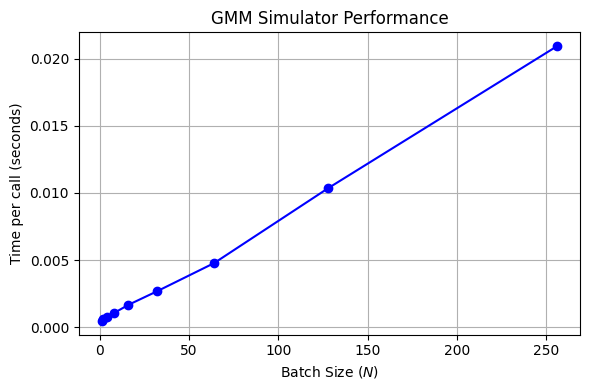

In [13]:
utils.benchmark_time([1,2,4,8,16,32,64,128,256],lambda n: model(true_params,np.arange(n)))

In [5]:
import transcriptional_dynamics as td
td_sim = td.snapshot_simulator()

import transcriptional_dynamics2 as td2

In [6]:
#### Model parameters 
sample_size = 300
kplus = 30
kminus = 10
rburst = 10
diffusivity = 0.1

true_params = np.array([kplus,rburst,diffusivity])
num_params = true_params.shape[0]


T,dt = 5,0.01
### These heterogeneities allow for too many, too small nuclei. 
# lengths = np.random.exponential(scale = 1/np.exp(2),size=(sample_size,))
# sites = np.random.uniform(np.zeros(shape=(sample_size,)),lengths,size = (sample_size,))

# The heterogeneities below allow for enough non-zero count RNA. 
bp,gp = 2,4
lengths = np.random.gamma(shape = gp, scale = 1/gp, size = (sample_size,))
sites = np.random.beta(a = bp,b = bp, size = (sample_size,)) * lengths

# homogeneous
#lengths = np.ones(shape = (sample_size,))
#sites = 0.5*lengths

length_index = np.arange(sample_size)
print(np.var(lengths), np.var(sites))


def bndry_func(x,ind,i=length_index): # ind is the wrong kind of indices, these are internal to the smfish simulator.
    return (x > 0) & (x < lengths[i[ind]])
data_ = td_sim.simulate(kplus, kminus, rburst, diffusivity, T, dt, sites, bndry_func)
data = np.array([np.asarray(d) for d in data_],dtype=object)

0.25508106537375197 0.12386381005357815


In [2]:
import transcriptional_dynamics as td
import transcriptional_dynamics2 as td2
td_sim = td.snapshot_simulator()

Warming up JIT (first call compiles)…
Mean mRNA count : 25.07
Fraction zero   : 0.00
Done.


Warming up JIT (first call compiles)…
Mean mRNA count : 24.81
Fraction zero   : 0.01
Done.
Running benchmarks...
Batch 1: 0.000054 sec
Batch 2: 0.000096 sec
Batch 4: 0.000189 sec
Batch 8: 0.000398 sec
Batch 16: 0.000755 sec
Batch 32: 0.001517 sec
Batch 64: 0.003002 sec
Batch 128: 0.006967 sec
Batch 256: 0.013775 sec
Average increase in seconds per sample: 4.9366914470283516e-05


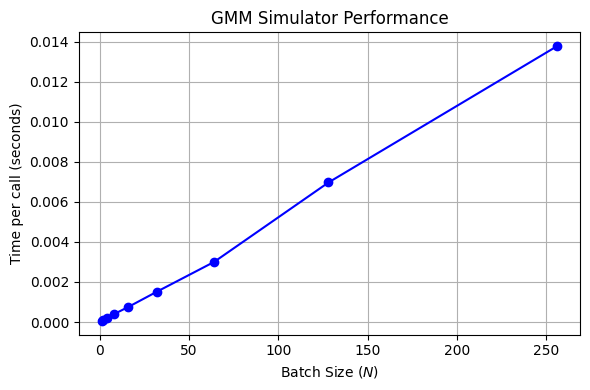

In [ ]:
rng = np.random.default_rng(42)

#### Model parameters 
sample_size = 300
kplus = 30.0
kminus = 10.0
rburst = 10.0
diffusivity = 0.1

true_params = np.array([kplus,rburst,diffusivity])
num_params = true_params.shape[0]

T,dt = 5,0.01
bp, gp  = 2, 4
lengths = rng.gamma(shape=gp, scale=1.0 / gp, size=sample_size)
sites   = rng.beta(a=bp, b=bp, size=sample_size) * lengths

# Cast to float64 — njit is strict about dtypes
lengths = lengths.astype(np.float64)
sites   = sites.astype(np.float64)

print("Warming up JIT (first call compiles)…")
data_list = td2.simulate_njit(kplus, kminus, rburst, diffusivity, T, dt, sites, lengths)

data = np.array([np.asarray(d) for d in data_list],dtype = object)

counts = np.array([len(d) for d in data])
print(f"Mean mRNA count : {counts.mean():.2f}")
print(f"Fraction zero   : {(counts == 0).mean():.2f}")
print("Done.")

utils.benchmark_time([1,2,4,8,16,32,64,128,256],lambda n: td2.simulate_njit(kplus, kminus, rburst, diffusivity, T, dt, sites[:n], lengths[:n]))